GLMsingle Desing Matrices

In [ ]:
# GLM Single - create design matrices
import os, glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib

home_dir = os.getcwd()
data_dir = os.path.join(home_dir, 'raw_pupil')
pupil_subj_dirs = sorted([d for d in glob.glob(os.path.join(data_dir, '*')) if d.split('/')[-1] != 'sub-000'])
output_dir = os.path.join(home_dir, 'GLMsingle_outputs')
os.makedirs(output_dir, exist_ok=True)

all_dms = {}

for subj_dir in pupil_subj_dirs:
    subj = subj_dir.split('/')[-1]

    # not all participants were used in the final analysis
    if subj in ['sub-001', 'sub-002', 'sub-003', 'sub-010', 'sub-011', 'sub-012', 
                'sub-013', 'sub-014', 'sub-015', 'sub-016', 'sub-017', 'sub-018']:

        print(f'Processing {subj}...')
        
        subj_dms = []
        events_files = sorted(glob.glob(os.path.join(subj_dir, '*_events.tsv')))
        events_files = events_files[1:] # skip run-0

        params_files = sorted(glob.glob(os.path.join(subj_dir, '*_params.csv')))
        params_files = params_files[1:] # skip run-0

        for i, events_file in enumerate(events_files):
            events_df = pd.read_csv(events_file, sep='\t')
            params_df = pd.read_csv(params_files[i])
            
            bold_path = os.path.join(home_dir, 'fmriprep_Ana', f'{subj}', 'ses-01', 'func', f'{subj}_ses-01_task-Gabor_run-{i+1}_part-mag_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz')
            bold_volumes = nib.load(bold_path).get_fdata().shape[3]
            print(f'{subj} run {i+1} has {bold_volumes} volumes')

            run_id = events_file.split('/')[-1].split('_')[2]
            run_time = int(events_df['onset'].iloc[-1] + events_df['duration'].iloc[events_df['duration'].last_valid_index()])
            tr = 2
            n_volumes = run_time // tr
            print(f'{subj} run {i+1} has {n_volumes} volumes based on run time {run_time}s and TR {tr}s')
            if n_volumes != bold_volumes:
                n_volumes = bold_volumes
                print(f'Missmatch between run time and actual number of volumes, using {bold_volumes} volumes instead\n')

            conditions = sorted(events_df['condition'].unique()) # ['blank', 'empty', 'left', 'right']
            dm = np.zeros((n_volumes, len(conditions) - 1)) # we do not code blank trials

            for i, cond in enumerate(params_df['condition']):
                if (cond == conditions[1]):  # empty
                    dm[i * tr, 0] = 1
                elif cond == conditions[2]:  # left
                    dm[i * tr, 1] = 1
                elif cond == conditions[3]:  # right
                    dm[i * tr, 2] = 1
            
            subj_dms.append(dm)

        all_dms[subj] = subj_dms

In [ ]:
# Example design matrix & inspection
subj = 'sub-001'
run = 1

plt.figure(figsize=(10,30))
plt.imshow(all_dms[subj][run-1], aspect='auto', interpolation='none')
plt.title(f'Design Matrix for {subj} run-0{run}')
plt.xlabel('Conditions')
plt.ylabel('Time (TR)')
plt.xticks(ticks=np.arange(len(conditions) - 1), labels=conditions[1:])
yticks = np.arange(0, len(all_dms[subj][run-1]), 2)
ylabels = np.arange(1, len(yticks) + 1)

plt.yticks(ticks=yticks, labels=ylabels, size=5)
plt.show()

FMRIPREP Sanity Checks

In [ ]:

import os, glob
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
from nilearn.masking import apply_mask
from nilearn.image import load_img
from glmsingle.glmsingle import GLM_single

home_dir = os.getcwd()
fmri_dir = os.path.join(home_dir, 'fmriprep_Ana')
pupil_dir = os.path.join(home_dir, 'raw_pupil')

subjects = sorted([folder for folder in os.listdir(fmri_dir) if folder.startswith('sub-') and len(folder) == 7])
print(f'Found {len(subjects)} subjects: {subjects}')

tr = 2.0
stimdur = 0.5

all_events = {}
all_params = {}
all_bold = {}
all_masks = {}

for subj in subjects:
    events_files = sorted(glob.glob(os.path.join(pupil_dir, subj, '*events.tsv')))
    events_files = events_files[1:] # skip run-0
    params_files = sorted(glob.glob(os.path.join(pupil_dir, subj, '*params.csv')))
    params_files = params_files[1:] # skip run-0
    all_events[subj] = events_files
    all_params[subj] = params_files

    bold_files = sorted(glob.glob(os.path.join(fmri_dir, subj, 'ses-01', 'func', '*desc-preproc_bold.nii.gz')))
    mask_files = sorted(glob.glob(os.path.join(fmri_dir, subj, 'ses-01', 'func', '*desc-brain_mask.nii.gz')))
    all_bold[subj] = bold_files
    all_masks[subj] = mask_files


In [ ]:
# check if masks are run specific
subj = "sub-001"
check_masks = [nib.load(mask).get_fdata() for mask in all_masks[subj]]
print("number of masks:", len(check_masks))


for i in range(len(check_masks)):
    if i == len(check_masks)-1:
        print(f"{i} vs {1}: {np.all(check_masks[i] == check_masks[0])}")
    else:
        print(f"{i} vs {i+1}: {np.all(check_masks[i] == check_masks[i+1])}")

In [ ]:
# load bold
subj = 'sub-001'
run = 1
bold_path = all_bold[subj][run-1]
bold = nib.load(all_bold[subj][run-1])
bold_002 = nib.load(all_bold["sub-002"][run-1])
bold_011 = nib.load(all_bold["sub-011"][run-1])
bold_016 = nib.load(all_bold["sub-016"][run-1])
print("data shape:", bold.shape)
print("voxel size:", bold.header.get_zooms())

bold_data = bold.get_fdata()
bold_data_002 = bold_002.get_fdata()
bold_data_011 = bold_011.get_fdata()
bold_data_016 = bold_016.get_fdata()

print(bold_data[38:40, 38:40, 20:21, 0])

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(1,4,1)
plt.imshow(bold_data[39, :, :, 0].T, cmap='gray', origin='lower')
plt.title(f'{subj} run-0{run}')
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(bold_data_002[39, :, :, 0].T, cmap='gray', origin='lower')
plt.title(f'sub-002 run-0{run}')
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(bold_data_011[39, :, :, 0].T, cmap='gray', origin='lower')
plt.title(f'sub-011 run-0{run}')
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(bold_data_016[39, :, :, 0].T, cmap='gray', origin='lower')
plt.title(f'sub-016 run-0{run}')
plt.axis('off')
plt.show()

In [ ]:
print(bold_data.shape, 
      bold_data_002.shape, 
      bold_data_011.shape, 
      bold_data_016.shape)

In [ ]:
# plot time-series of a voxel
voxel_ts = bold_data[39, 45, 30, :]

plt.figure(figsize=(20, 4))
plt.plot(voxel_ts, 'o-', ms=4)
plt.xlim(-1, voxel_ts.size)
plt.ylabel('Signal intensity', fontsize=15)
plt.xlabel('Time (nr. of volumes)', fontsize=15)
plt.title(f'Voxel time-series for {subj} run-0{run}')
plt.show()


In [ ]:
voxel_mean = np.mean(bold_data, axis=3)
voxel_mean = voxel_mean[voxel_mean > 0]

plt.figure(figsize=(10, 4))
plt.hist(voxel_mean, bins=100)
plt.xlabel('Mean voxel intensity')
plt.ylabel('Number of voxels')
plt.title(f'Voxel intensity distribution for {subj} run-0{run}')
plt.show()

In [ ]:
from nilearn.maskers import NiftiMasker

# masking w/ niftimasker
mask_path = all_masks[subj][0]
mask = nib.load(mask_path)
mask_data = mask.get_fdata().astype(bool)
print("bold shape:", bold_data.shape)
print("mask shape:", mask_data.shape)

masker = NiftiMasker(mask_img=mask_path, 
                     standardize=False)

X = masker.fit_transform(bold_path)
bold_masked = masker.inverse_transform(X)
bold_masked_data = bold_masked.get_fdata()
print("bold masked shape:", bold_masked_data.shape)

In [ ]:
# get mean images
from nilearn import image
mean_bold_img = image.mean_img(bold).get_fdata()
mean_bold_masked_img = image.mean_img(bold_masked).get_fdata()

mean_bold_data = np.mean(bold_data, axis=3)
mean_bold_masked_data = np.mean(bold_masked_data, axis=3)

# both methods give simialr results up to 3 decimal places 
np.allclose(mean_bold_img, mean_bold_data, atol=1e-3)

In [ ]:
# visualize effect of masking
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(mean_bold_data[39, :, :].T, cmap='gray', origin='lower')
plt.title('Before masking (mean)'); plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(mean_bold_masked_data[39, :, :].T, cmap='gray', origin='lower')
plt.title('After masking (mean)'); plt.axis('off')
plt.show()

In [ ]:
# sanity checks on fmri prep and masking
print("MNI bold")
print("range:", np.min(mean_bold_data), np.max(mean_bold_data))
print("fraction of NaNs:", np.mean(np.isnan(mean_bold_data)))
print("fraction of zeros:", np.mean(mean_bold_data == 0))

print("\nMNI bold masked")
print("range:", np.min(mean_bold_masked_data), np.max(mean_bold_masked_data))
print("fraction of NaNs:", np.mean(np.isnan(mean_bold_masked_data)))
print("fraction of zeros:", np.mean(mean_bold_masked_data == 0))
print("fraction of zeros in masked brain:", np.mean((mean_bold_masked_data == 0) & mask_data))

In [ ]:
# masking using boolean indexing also works c:
bold_masked_bool = np.where(mask_data[..., None], bold_data, 0.0)
print(np.all(bold_masked_bool == bold_masked_data))

GLMsinle Analysis

In [1]:

import os, glob
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nibabel as nib
from nilearn.masking import apply_mask
from nilearn.image import load_img
from glmsingle.glmsingle import GLM_single

home_dir = os.getcwd()
fmri_dir = os.path.join(home_dir, 'fmriprep_Ana')
pupil_dir = os.path.join(home_dir, 'raw_pupil')

subjects = sorted([folder for folder in os.listdir(fmri_dir) if folder.startswith('sub-') and len(folder) == 7])
print(f'Found {len(subjects)} subjects: {subjects}')

tr = 2.0
stimdur = 0.5

all_events = {}
all_params = {}
all_bold = {}
all_masks = {}
all_masks_bool = {}

for subj in subjects:
    events_files = sorted(glob.glob(os.path.join(pupil_dir, subj, '*events.tsv')))
    events_files = events_files[1:] # skip run-0
    params_files = sorted(glob.glob(os.path.join(pupil_dir, subj, '*params.csv')))
    params_files = params_files[1:] # skip run-0
    all_events[subj] = events_files
    all_params[subj] = params_files

    bold_files = sorted(glob.glob(os.path.join(fmri_dir, subj, 'ses-01', 'func', '*desc-preproc_bold.nii.gz')))
    mask_files = sorted(glob.glob(os.path.join(fmri_dir, subj, 'ses-01', 'func', '*desc-brain_mask.nii.gz')))
    all_bold[subj] = bold_files
    all_masks[subj] = mask_files

    all_masks_bool[subj] = [nib.load(mask).get_fdata().astype(bool) for mask in mask_files]


Found 12 subjects: ['sub-001', 'sub-002', 'sub-003', 'sub-010', 'sub-011', 'sub-012', 'sub-013', 'sub-014', 'sub-015', 'sub-016', 'sub-017', 'sub-018']


In [2]:
home_dir = os.getcwd()
glmsingle_dir = os.path.join(home_dir, 'GLMsingle_outputs_Ana')
bold_dir = os.path.join(home_dir, 'derivatives')

all_glm_fits = {}
all_betas = {}

for subj in sorted(os.listdir(glmsingle_dir)):
    subj_path = os.path.join(glmsingle_dir, subj)
    if not os.path.isdir(subj_path):
        continue

    fit_path = os.path.join(subj_path, 'test', 'ses-01', 'TYPED_FITHRF_GLMDENOISE_RR.npy')

    if not os.path.exists(fit_path):
        print(f"Missing GLMsingle file for {subj}: {fit_path}")
        continue

    glm_fit = np.load(fit_path, allow_pickle=True).item()
    all_glm_fits[subj] = glm_fit
    betas = glm_fit['betasmd']
    all_betas[subj] = betas
    print(f'{subj} has betas shape {betas.shape}')

sub-001 has betas shape (77, 95, 61, 669)
sub-002 has betas shape (77, 95, 61, 672)
sub-003 has betas shape (77, 95, 61, 672)
sub-010 has betas shape (77, 95, 61, 668)
sub-011 has betas shape (77, 95, 61, 672)
sub-012 has betas shape (77, 95, 61, 672)
sub-013 has betas shape (77, 95, 61, 672)
sub-014 has betas shape (77, 95, 61, 672)
sub-015 has betas shape (77, 95, 61, 672)
sub-016 has betas shape (77, 95, 61, 672)
sub-017 has betas shape (77, 95, 61, 672)
sub-018 has betas shape (77, 95, 61, 672)


In [4]:
# sanity checks on betas
subj = 'sub-002'
masks = [nib.load(mask).get_fdata().astype(bool) for mask in all_masks[subj]]
common_mask = np.logical_and.reduce(masks)
print("common mask shape:", common_mask.shape)

betas = all_betas[subj]
print("betas shape:", betas.shape)
print("range:", np.nanmin(betas), np.nanmax(betas))
print("fraction of NaNs:", np.mean(np.isnan(betas)))
print("fraction of zeros:", np.mean(betas == 0))

betas_masked = np.where(common_mask[..., None], betas, 0.0)
print("betas shape:", betas_masked.shape)
print("range:", np.nanmin(betas_masked), np.nanmax(betas_masked))
print("fraction of NaNs (inside masked brain):", np.mean(np.isnan(betas_masked)))
print("fraction of zeros:", np.mean(betas_masked == 0))

common mask shape: (77, 95, 61)
betas shape: (77, 95, 61, 672)
range: -17025.1 19298.389
fraction of NaNs: 0.5839740932061899
fraction of zeros: 0.0
betas shape: (77, 95, 61, 672)
range: -14764.906 19298.389
fraction of NaNs (inside masked brain): 0.0
fraction of zeros: 0.6068845735800007


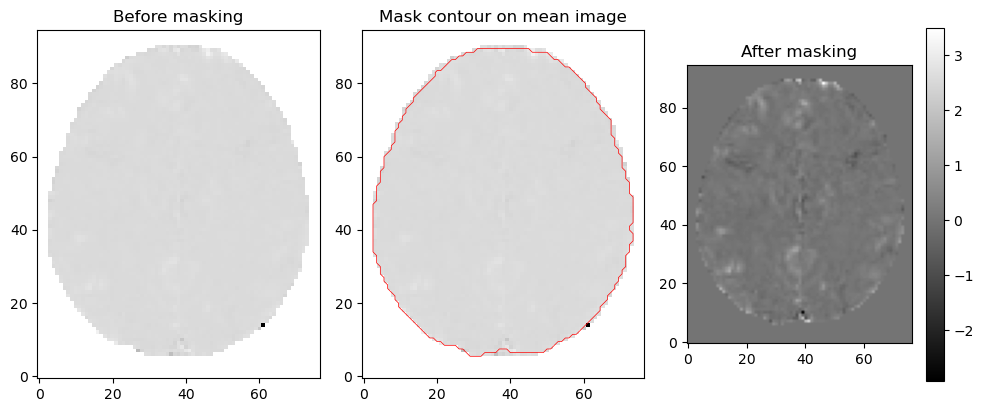

In [5]:
mean_before = np.mean(betas, axis=3)
mean_after  = np.mean(betas_masked, axis=3)

plt.figure(figsize=(10, 4))
plt.subplot(1, 3, 1)
plt.imshow(mean_before[:, :, 39].T, cmap='gray', origin='lower')
plt.title('Before masking')

plt.subplot(1, 3, 2)
plt.imshow(mean_before[:, :, 39].T, cmap='gray', origin='lower')
plt.contour(common_mask[:, :, 39].T, colors='r', linewidths=0.5)
plt.title('Mask contour on mean image')

plt.subplot(1, 3, 3)
plt.imshow(mean_after[:, :, 39].T, cmap='gray', origin='lower')
plt.title('After masking')
plt.colorbar()

plt.tight_layout()
plt.show()

In [6]:
# create common masks across runs for each subject
common_masks = {}

for subj in all_masks_bool:
    masks = all_masks_bool[subj]
    common_mask = np.logical_and.reduce(masks)
    common_masks[subj] = common_mask

print("number of common masks:", len(common_masks))

number of common masks: 12


In [7]:
# mask the beta maps for each subject
all_betas_masked = {}

for subj in all_betas:
    betas = all_betas[subj]
    common_mask = common_masks[subj]
    betas_masked = np.where(common_mask[..., None], betas, 0.0)
    all_betas_masked[subj] = betas_masked

    print(f'\n{subj} sanity check after masking')
    print("betas shape:", betas_masked.shape)
    print("range:", np.nanmin(betas_masked), np.nanmax(betas_masked))
    print("fraction of NaNs (inside masked brain):", np.mean(np.isnan(betas_masked)))
    print("fraction of zeros:", np.mean(betas_masked == 0))
    


sub-001 sanity check after masking
betas shape: (77, 95, 61, 669)
range: -28693.256 65094.99
fraction of NaNs (inside masked brain): 8.516074089844582e-05
fraction of zeros: 0.597940454713535

sub-002 sanity check after masking
betas shape: (77, 95, 61, 672)
range: -14764.906 19298.389
fraction of NaNs (inside masked brain): 0.0
fraction of zeros: 0.6068845735800007

sub-003 sanity check after masking
betas shape: (77, 95, 61, 672)
range: -11986.165 101024.15
fraction of NaNs (inside masked brain): 6.947323599610054e-05
fraction of zeros: 0.6004952769404883

sub-010 sanity check after masking
betas shape: (77, 95, 61, 668)
range: -915.31714 1311.2327
fraction of NaNs (inside masked brain): 0.0
fraction of zeros: 0.6184104075389666

sub-011 sanity check after masking
betas shape: (77, 95, 61, 672)
range: -890.897 2148.2817
fraction of NaNs (inside masked brain): 0.0
fraction of zeros: 0.6245195701623657

sub-012 sanity check after masking
betas shape: (77, 95, 61, 672)
range: -1244.144

In [ ]:
# outlier correction & beta distributions per subject
all_betas_masked_oc = {}

for subj in all_betas_masked:
    print(f"Running for {subj} ...")
    
    betas = all_betas_masked[subj]
    p1, p99 = np.quantile(betas, [0.02, 0.98], axis=3, keepdims=True)
    betas_oc = np.clip(betas, p1, p99)
    print("range:", np.nanmin(betas_oc), np.nanmax(betas_oc))

    all_betas_masked_oc[subj] = betas_oc


Running for sub-001 ...
range: -8494.825 10196.111445312494
Running for sub-002 ...
range: -10314.5984765625 12223.100117187523
Running for sub-003 ...
range: -2734.3015283203126 1854.346406250001
Running for sub-010 ...
range: -537.7684204101563 537.8415869140618
Running for sub-011 ...
range: -366.19676696777344 365.6530511474614
Running for sub-012 ...
range: -816.5815710449219 882.6527856445315
Running for sub-013 ...
range: -3598.4166845703126 3384.682182617194
Running for sub-014 ...
range: -2096.0119775390626 2074.6176513671876
Running for sub-015 ...
range: -3361.181484375 4702.177031250009
Running for sub-016 ...
range: -1109.5102099609376 598.1624096679698
Running for sub-017 ...
range: -525.7002575683593 482.28205871582054
Running for sub-018 ...
